# Simulation Analysis


### 1. Import Packages
Here we will be using the reading and writing tools that come with the ParFlow tools package.  

In [1]:
from set_demo_defaults import *
import xarray as xr
import numpy as np
import os
from glob import glob
import matplotlib.pyplot as plt

import parflow as pf
from parflow.tools.fs import get_absolute_path
from parflow.tools.io import write_pfb, read_pfb
from parflow import Run
import parflow.tools.hydrology as hydro

#setting the directory name that we will read our outputs from
capillary = True #status of capillary forcing -- true or false 
#cycle 5 for false, 1 for true
cycle = 1

if cycle>1:
    if capillary:
        sim_type = 'cap' #cap: capillarity, no-cap: no capillarity
        run_name = f"lil_washita_via_conus2_cycle{cycle}"
    else:
        sim_type = 'no-cap' #cap: capillarity, no-cap: no capillarity
        run_name = f"no_cap_lil_washita_via_conus2_cycle{cycle}"
else:
    if capillary:
        sim_type = 'cap' #cap: capillarity, no-cap: no capillarity
        run_name = "lil_washita_via_conus2"
    else:
        sim_type = 'cap' #cap: capillarity, no-cap: no capillarity
        run_name = "no_cap_lil_washita_via_conus2"



#run_dir = get_absolute_path(f'outputs/{run_name}')

#run_dir = get_absolute_path(f"/scratch/network/ms6985//outputs/{run_name}')

# set the directory paths where you want to write your subset files
grid       = "conus2"
start      = "2003-10-01"
end        = "2004-10-01"
home       = "/scratch/network/ms6985" #make scratch home again
base_dir   = os.path.join(home, "subsettools_tutorial")
output_dir = os.path.join(base_dir, "outputs")
run_dir    = os.path.join(output_dir, f"{run_name}_{grid}_{end[:4]}WY")

print(run_dir)

/scratch/network/ms6985/subsettools_tutorial/outputs/lil_washita_via_conus2_conus2_2004WY


####  2. Read in the domain properties
First we will load the run from the pfidb file and get the properties using the [data_accessor](https://parflow.readthedocs.io/en/latest/tutorials/data_accessor.html?highlight=data_accessor) and by reading out the keys we need from the model object. 


In [2]:
run = Run.from_definition(f'{run_dir}/{run_name}.pfidb')
data = run.data_accessor
nt = len(data.times)
nx = data.shape[2]
ny = data.shape[1]
nz = data.shape[0]
dx = data.dx
dy = data.dy
dz = data.dz

print(nt,nx,ny,nz,dx,dy,dz)

porosity = data.computed_porosity 
specific_storage = data.specific_storage 
mannings = run.Mannings.Geom.domain.Value
#mannings = mannings*np.ones((ny, nx))
#print(mannings)

## remove input filenames for TopoSlopes to force the data accessor to read the output slopes
## this fixes a windows issue
run.TopoSlopesX.FileName = 'slope_x.pfb'
run.TopoSlopesY.FileName = 'slope_y.pfb'

slopex = data.slope_x 
slopey = data.slope_y 
mask = data.mask

# formatting the mask so that values outside the domain are NA and inside the domain are 1
nanmask=mask.copy()
nanmask[nanmask == 0] = 'NaN'
nanmask[nanmask > 0] = 1

Solver: Field BinaryOutDir is not part of the expected schema <class 'parflow.tools.database.generated.Solver'>
  - nt
  - sw_ini
  - hkdepth
  - wtfact
  - trsmx0
  - smpmax
  - pondmx


/home/SHARED/virtual-environments/parflow-shared/conda/lib/python3.11/site-packages/parflow/tools/io.py:1494: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_name, delim_whitespace=True, skiprows=2, header=None)


8761 64 32 10 1000.0 1000.0 [2.0e+02 1.0e+02 5.0e+01 2.5e+01 1.0e+01 5.0e+00 1.0e+00 6.0e-01 3.0e-01
 1.0e-01]


In [3]:
from parflow.tools.io import read_pfb
mannings = read_pfb(f'{run_dir}/mannings.pfb')
print(mannings)
print(np.shape(mannings))

[[[9.72222222e-06 2.50000000e-05 2.50000000e-05 ... 9.72222222e-06
   2.77777778e-05 2.77777778e-05]
  [2.50000000e-05 2.50000000e-05 9.72222222e-06 ... 2.77777778e-05
   9.72222222e-06 9.72222222e-06]
  [2.50000000e-05 9.72222222e-06 9.72222222e-06 ... 2.77777778e-05
   2.77777778e-05 2.77777778e-05]
  ...
  [1.52777778e-05 1.52777778e-05 9.72222222e-06 ... 2.50000000e-05
   2.77777778e-05 9.72222222e-06]
  [9.72222222e-06 9.72222222e-06 9.72222222e-06 ... 2.50000000e-05
   9.72222222e-06 9.72222222e-06]
  [1.52777778e-05 9.72222222e-06 9.72222222e-06 ... 2.50000000e-05
   9.72222222e-06 9.72222222e-06]]]
(1, 32, 64)


#### 4. Read the simulation output files


In [4]:
#list all pressure files from outputs
lw_press_files = glob(f'{run_dir}/*out.press*.pfb')
#print(lw_press_files)
#read in all pressure files into a 3D NParray
pressure_arrays = pf.read_pfb_sequence(lw_press_files) * nanmask

#list all saturation files from outputs
lw_satur_files = glob(f'{run_dir}/*out.satur*.pfb')
#read in all pressure files into a 3D NParray
saturation_arrays = pf.read_pfb_sequence(lw_satur_files) * nanmask

import pandas as pd

#list all ET files from outputs
lw_clm_output_files = glob(f'{run_dir}/*out.clm_output*.pfb')
CLM_data = pf.read_pfb_sequence(lw_clm_output_files) #* nanmask
#print out all CLM variables avilable
## create data frame for CLM output ET vars
clm_output = pd.DataFrame({'T [mm/s]':CLM_data[:,8,0,0],'Ebs [mm/s]':CLM_data[:,6,0,0],'Qflux infil [mm/s]':CLM_data[:,9,0,0],'Qflux irrig [mm/s]':CLM_data[:,12,0,0],'qflx_evap_grnd [mm/s]':CLM_data[:,5,0,0] })
## the variables we use here are chosen to represent the fluxes passed to ParFlow, detailed below
#clm_output_full = pd.DataFrame({'T [mm/s]':CLM_data[:,8,0,:],'Ebs [mm/s]':CLM_data[:,6,0,:],'Qflux infil [mm/s]':CLM_data[:,9,0,:],'Qflux irrig [mm/s]':CLM_data[:,12,0,:],'qflx_evap_grnd [mm/s]':CLM_data[:,5,0,:] })

clm_output_T_mmps   = CLM_data[:,8,:,:]
clm_output_Ebs_mmps = CLM_data[:,6,:,:]
clm_output_T_Grnd_K = CLM_data[:,11,:,:]
clm_output_SWE_mm   = CLM_data[:,10,:,:]

#### 5. Calculate water balance
We will be using the hydrology tools to calculate the water balance. You can find more information on the tools [here](https://parflow.readthedocs.io/en/latest/tutorials/hydrology.html).

In [5]:
# Set up x and z to match the shape of the ParFlow grid
x = np.arange(0.0,(nx+1)*dx,dx)
y = np.arange(0.0,(ny+1)*dy,dy)
z = np.zeros(nz+1)
z[1:] = np.cumsum(dz)

subsurface_storage = np.zeros(nt)
subsurface_storage_arr= np.zeros((nt,nz, ny, nx))
surface_storage = np.zeros(nt)
wtd = np.zeros((nt, ny, nx))
et = np.zeros(nt)
overland_flow = np.zeros((nt, ny, nx))
data.time = 0

for i, (pressure, saturation) in enumerate(zip(pressure_arrays, saturation_arrays)):
    subsurface_storage[i, ...] = np.sum(hydro.calculate_subsurface_storage(porosity, pressure, saturation, specific_storage, dx, dy, dz, mask = nanmask),axis=(0, 1, 2))
    subsurface_storage_arr[i, ...] = hydro.calculate_subsurface_storage(porosity, pressure, saturation, specific_storage, dx, dy, dz, mask = nanmask)
    # total surface storage for this time step is the summation of substorage surface across all x/y slices
    surface_storage[i, ...] = np.sum( hydro.calculate_surface_storage(pressure, dx, dy, mask = nanmask),axis=(0, 1))
    wtd[i, ...] = hydro.calculate_water_table_depth(pressure, saturation, dz)
    
    data.time = i
    if i != 0:
        if data.et is not None:
            # total ET for this time step is the summation of ET values across all x/y/z slices
            et[i, ...] = np.sum(hydro.calculate_evapotranspiration(data.et, dx, dy, dz, mask = nanmask),axis=(0, 1, 2))

 
    overland_flow[i, ...] = hydro.calculate_overland_flow_grid(pressure, slopex, slopey, mannings, dx, dy, mask = nanmask)

In [6]:
print(np.shape(subsurface_storage_arr))

Delta_x = 1000 #1 km grid size in x direction
Delta_y = 1000 #1 km grid size in y direction
Delta_z = [200, 100, 50, 25, 10, 5, 1, 0.6, 0.3, 0.1] #cell thickness in vertical direction from bottom to top [m]

soil_moisture_1m = np.sum(subsurface_storage_arr[:,-3:-1,:,:],axis=1)/(Delta_x*Delta_y*1) #[m3/m3]
soil_moisture_2m = np.sum(subsurface_storage_arr[:,-4:-1,:,:],axis=1)/(Delta_x*Delta_y*2) #[m3/m3]
soil_moisture_point10cmavg = subsurface_storage_arr[:,-1,:,:]/(Delta_x*Delta_y*Delta_z[-1]) #[m3/m3]  #10cm thick cell
soil_moisture_point25cmavg = subsurface_storage_arr[:,-2,:,:]/(Delta_x*Delta_y*Delta_z[-2]) #[m3/m3]  #25cm thick cell

print(np.shape(soil_moisture_1m))
print(np.shape(soil_moisture_2m))
print(np.argwhere(soil_moisture_1m==np.nan))

(8761, 10, 32, 64)
(8761, 32, 64)
(8761, 32, 64)
[]


### Plot Static maps of the simulation outputs

(8761, 32, 64)
(8761, 10, 32, 64)


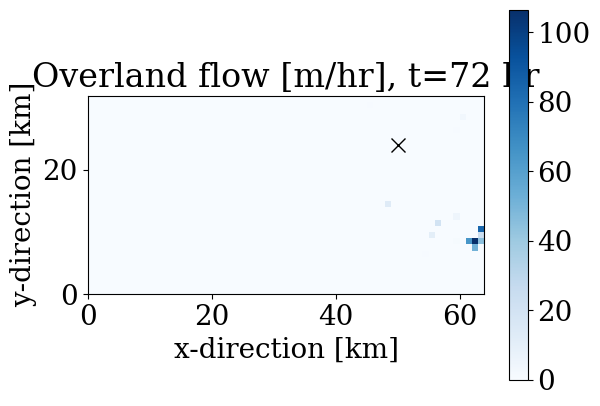

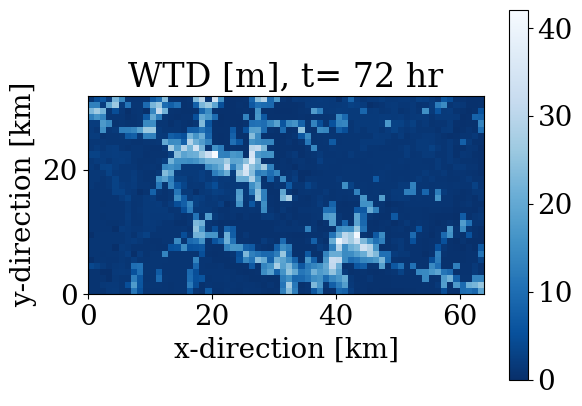

('eflx_lh_tot', 'eflx_lwrad_out', 'eflx_sh_tot', 'eflx_soil_grnd', 'qflx_evap_tot', 'qflx_evap_grnd', 'qflx_evap_soi', 'qflx_evap_veg', 'qflx_tran_veg', 'qflx_infl', 'swe_out', 't_grnd', 'qflx_qirr', 't_soil')


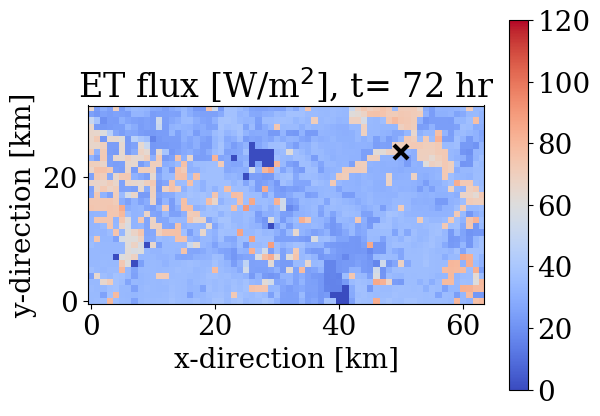

In [7]:
#CLM data array format 
# reading the CLM file PFCLM_SC.out.clm_output.<file number>.C.pfb
# variables are by layer:
# 0 eflx_lh_tot:  total latent heat flux (Wm-2)  
# 1 eflx_lwrad_out: total upward LW radiation (Wm-2)  
# 2 eflx_sh_tot: total sensible heat flux (Wm-2)  
# 3 eflx_soil_grnd: ground heat flux (Wm-2)    
# 4 qflx_evap_tot: net veg. evaporation and transpiration and soil evaporation (mms-1)  
# 5 qflx_evap_grnd: ground evaporation (mms-1)   
# 6 qflx_evap_soi: soil evaporation (mms-1)   
# 7 qflx_evap_veg: vegetation evaporation (canopy) and transpiration (mms-1)   
# 8 qflx_tran_veg: transpiration (mms-1)  
# 9 qflx_infl: infiltration flux (mms-1)   
# 10 swe_out: SWE (mm)   
# 11 t_grnd: ground temperature (K)  
# 12 irrigation flux
# 13 - 24 Soil temperature by layer (K)

print(np.shape(overland_flow))
print(np.shape(pressure_arrays))

icount = 72


fig, ax = plt.subplots(1)
ax.set_title("Overland flow [m/hr], t={} hr".format(icount))
plt.plot(x[50]/1e3,y[24]/1e3,'x',markersize=10,color='k',markeredgewidth=1)
#plt.imshow(overland_flow[icount,:,:], cmap="Blues", origin='lower')
im = ax.pcolormesh(x/1e3, y/1e3, overland_flow[icount,:,:], cmap="Blues") 
plt.colorbar(im, ax=ax)
plt.xlabel('x-direction [km]')
plt.ylabel('y-direction [km]')
ax.set_aspect('equal')
plt.savefig(f'little_washita_time{icount}hr_sim_type{sim_type}_overland_cycle{cycle}.pdf',bbox_inches='tight', dpi = 600)
plt.show()

# To equalize our aspect ratio

fig, ax = plt.subplots(1)
ax.set_title("WTD [m], t= {} hr".format(icount))
#plt.imshow(wtd[icount,:,:], cmap="Blues_r", origin='lower')
im = ax.pcolormesh(x/1e3, y/1e3, wtd[icount,:,:], cmap="Blues_r") 
plt.colorbar(im, ax=ax)
plt.xlabel('x-direction [km]')
plt.ylabel('y-direction [km]')
ax.set_aspect('equal')
plt.savefig(f'little_washita_time{icount}hr_sim_type{sim_type}_WTD_cycle{cycle}.pdf',bbox_inches='tight', dpi = 600)
plt.show()

#print out all CLM variables avilable
print(data.clm_output_variables)
# set time
fig, ax = plt.subplots(1)
data.time = icount
# fileter out inactive cellsfig, ax = plt.subplots(1)
ax.set_title("ET flux [W/m$^2$], t= {} hr".format(icount))
LH_plot = np.where(data.clm_output(field='eflx_lh_tot') > -99, data.clm_output(field='eflx_lh_tot'), 0.)
#im = ax.pcolormesh(x/1e3, y/1e3, LH_plot, cmap="coolwarm") 
im = plt.imshow(LH_plot, cmap="coolwarm", origin='lower',vmin=0, vmax=120)
plt.plot(x[50]/1e3,y[24]/1e3,'x',markersize=10,color='k',markeredgewidth=3)
plt.colorbar()
#plt.colorbar(im, ax=ax)
plt.xlabel('x-direction [km]')
plt.ylabel('y-direction [km]')
ax.set_aspect('equal')
plt.savefig(f'little_washita_time{icount}hr_sim_type{sim_type}_ETfluxes_cycle{cycle}.pdf',bbox_inches='tight', dpi = 600)
plt.show()

In [8]:
print(np.shape(subsurface_storage_arr))

Delta_x = 1000 #1 km grid size in x direction
Delta_y = 1000 #1 km grid size in y direction
Delta_z = [200, 100, 50, 25, 10, 5, 1, 0.6, 0.3, 0.1] #cell thickness in vertical direction from bottom to top [m]

soil_moisture_1m = np.sum(subsurface_storage_arr[:,-3:-1,:,:],axis=1)/(Delta_x*Delta_y*1) #[m3/m3]
soil_moisture_2m = np.sum(subsurface_storage_arr[:,-4:-1,:,:],axis=1)/(Delta_x*Delta_y*2) #[m3/m3]
soil_moisture_point10cmavg = subsurface_storage_arr[:,-1,:,:]/(Delta_x*Delta_y*Delta_z[-1]) #[m3/m3]  #10cm thick cell
soil_moisture_point25cmavg = subsurface_storage_arr[:,-2,:,:]/(Delta_x*Delta_y*Delta_z[-2]) #[m3/m3]  #25cm thick cell

print(np.shape(soil_moisture_1m))
print(np.shape(soil_moisture_2m))
print(np.argwhere(soil_moisture_1m==np.nan))

(8761, 10, 32, 64)
(8761, 32, 64)
(8761, 32, 64)
[]


In [9]:
# ============================================================
# Make a 4-panel video of:
#   1) WTD [m]
#   2) ET flux [mm/hr]
#   3) Ground Temp [C]
#   4) SWE [mm]
# with time shown at the top
# ============================================================
'''
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from datetime import datetime, timedelta

# ------------------------------------------------------------
# Time array example
# Adjust the start date if needed
# ------------------------------------------------------------
d = datetime(2003, 10, 1, 0, 0)
nt = wtd.shape[0]
t_time_datetime = [d + timedelta(hours=i) for i in range(nt)]

# ------------------------------------------------------------
# Derived variables
# ------------------------------------------------------------
et_mmhr = (clm_output_T_mmps + clm_output_Ebs_mmps) * 3600.0
grnd_temp_C = clm_output_T_Grnd_K - 273.16
swe_mm = clm_output_SWE_mm
overland_flow_mhr = overland_flow.copy()
# ------------------------------------------------------------
# Optional masking if you have invalid values
# Uncomment and edit if needed
# ------------------------------------------------------------
# wtd_plot = np.where(wtd > -999, wtd, np.nan)
# et_plot = np.where(et_mmhr > -999, et_mmhr, np.nan)
# grnd_plot = np.where(grnd_temp_C > -999, grnd_temp_C, np.nan)
# swe_plot = np.where(swe_mm > -999, swe_mm, np.nan)

# If no masking needed:
soil_moisture_1m_plot = soil_moisture_1m*nanmask[0,:,:]
et_plot = et_mmhr*nanmask[0,:,:]
grnd_plot = grnd_temp_C*nanmask[0,:,:]
swe_plot = swe_mm*nanmask[0,:,:]
overland_flow_mhr = overland_flow_mhr*nanmask[0,:,:]
# ------------------------------------------------------------
# Color limits
# You can change these manually if you want
# ------------------------------------------------------------
soil_moisture_1m_vmin, soil_moisture_1m_vmax = 0, 0.4
et_vmin, et_vmax = 0, 0.12

grnd_vmin = np.nanpercentile(grnd_plot, 2)
grnd_vmax = np.nanpercentile(grnd_plot, 98)

swe_vmin = np.nanpercentile(swe_plot, 2)
swe_vmax = np.nanpercentile(swe_plot, 98)

overland_flow_mhr_vmin = 0#np.nanpercentile(overland_flow_mhr, 2)
overland_flow_mhr_vmax = np.nanpercentile(overland_flow_mhr, 98)

print("soil_moisture_1m shape:", soil_moisture_1m_plot.shape)
print("ET shape:", et_plot.shape)
print("Ground Temp shape:", grnd_plot.shape)
print("SWE shape:", swe_plot.shape)

print("Ground temp limits:", grnd_vmin, grnd_vmax)
print("SWE limits:", swe_vmin, swe_vmax)
print("Overland limits:", overland_flow_mhr_vmin,overland_flow_mhr_vmax)

# ------------------------------------------------------------
# Video settings
# ------------------------------------------------------------
fps = 10
step = 24
writer = animation.PillowWriter(fps=fps)
video_name = f"{run_dir}/../little_Washita_time_video_sim_type{sim_type}_WTD_ET_GrndTemp_SWE.gif"

# ------------------------------------------------------------
# Create figure
# ------------------------------------------------------------
fig, axes = plt.subplots(2,2, figsize=(12, 10), constrained_layout=True)
ax1, ax2, ax3, ax4 = axes.ravel()

# Initial frame
icount = 0

im1 = ax1.pcolormesh(
    x / 1e3, y / 1e3, soil_moisture_1m_plot[icount, :, :],
    cmap="Blues", shading="auto", vmin=soil_moisture_1m_vmin, vmax=soil_moisture_1m_vmax
)
ax1.set_title("Soil Mois. 1m [-]")
ax1.set_xlabel("km")
ax1.set_ylabel("km")
ax1.set_aspect("equal")

im2 = ax2.pcolormesh(
    x / 1e3, y / 1e3, et_plot[icount, :, :],
    cmap="viridis", shading="auto", vmin=0, vmax=et_vmax
)
ax2.set_title("ET flux [mm/hr]")
ax2.set_xlabel("km")
ax2.set_ylabel("km")
ax2.set_aspect("equal")

im3 = ax3.pcolormesh(
    x / 1e3, y / 1e3, grnd_plot[icount, :, :],
    cmap="Reds", shading="auto", vmin=-20, vmax=grnd_vmax
)
ax3.set_title("Ground temp. $[^\circ C]$")
ax3.set_xlabel("km")
ax3.set_ylabel("km")
ax3.set_aspect("equal")

im4 = ax4.pcolormesh(
    x / 1e3, y / 1e3, overland_flow_mhr[icount, :, :],
    cmap="Blues", shading="auto", vmin=0, vmax=swe_vmax
)

ax4.set_title("Overland flow [m/hr]")
ax4.set_xlabel("km")
ax4.set_ylabel("km")
ax4.set_aspect("equal")

# Colorbars
cbar1 = fig.colorbar(im1, ax=ax1)
cbar2 = fig.colorbar(im2, ax=ax2)
cbar3 = fig.colorbar(im3, ax=ax3)
cbar4 = fig.colorbar(im4, ax=ax4)

#cbar1.set_label("[-]")
#cbar2.set_label("mm/hr")
#cbar3.set_label("C")
#cbar4.set_label("mm")

# Global title
suptitle = fig.suptitle(f"{t_time_datetime[icount]}", fontsize=36)

print(f"Creating video: {video_name}")

# ------------------------------------------------------------
# Write frames
# ------------------------------------------------------------
with writer.saving(fig, video_name, dpi=300):
    for icount in range(0, nt, step):

        im1.set_array(soil_moisture_1m_plot[icount, :, :].ravel())
        im2.set_array(et_plot[icount, :, :].ravel())
        im3.set_array(grnd_plot[icount, :, :].ravel())
        im4.set_array(overland_flow_mhr[icount, :, :].ravel())

        suptitle.set_text(f"{t_time_datetime[icount]}")

        writer.grab_frame()

        if icount % 50 == 0:
            print(f"Frame {icount}/{nt} complete...")

plt.close(fig)
print(f"Finished writing video: {video_name}")
'''

'\nimport numpy as np\nimport matplotlib.pyplot as plt\nimport matplotlib.animation as animation\nfrom datetime import datetime, timedelta\n\n# ------------------------------------------------------------\n# Time array example\n# Adjust the start date if needed\n# ------------------------------------------------------------\nd = datetime(2003, 10, 1, 0, 0)\nnt = wtd.shape[0]\nt_time_datetime = [d + timedelta(hours=i) for i in range(nt)]\n\n# ------------------------------------------------------------\n# Derived variables\n# ------------------------------------------------------------\net_mmhr = (clm_output_T_mmps + clm_output_Ebs_mmps) * 3600.0\ngrnd_temp_C = clm_output_T_Grnd_K - 273.16\nswe_mm = clm_output_SWE_mm\noverland_flow_mhr = overland_flow.copy()\n# ------------------------------------------------------------\n# Optional masking if you have invalid values\n# Uncomment and edit if needed\n# ------------------------------------------------------------\n# wtd_plot = np.where(wt

# plot average values throughout year

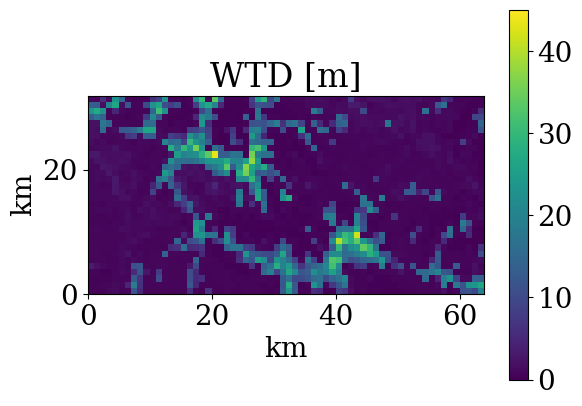

The mean water table depth is for cycle 1 is 4.611129378153829 m


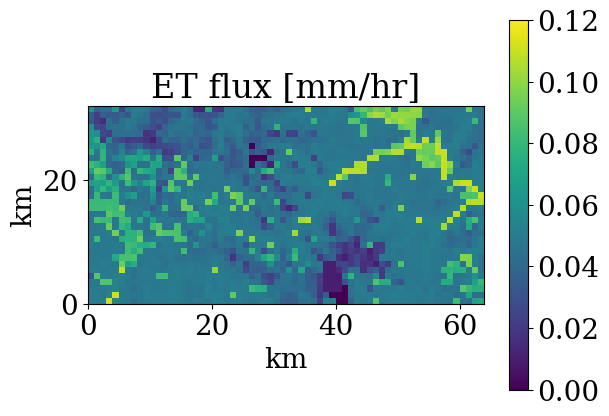

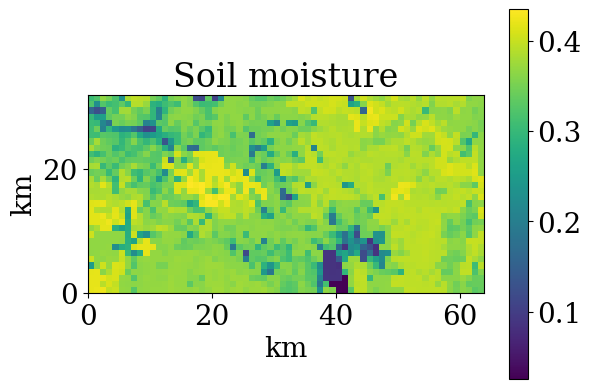

In [10]:
#Plot average ET in a year and average WTD
fig, ax = plt.subplots(1)
ax.set_title("WTD [m]".format(icount))
#plt.imshow(wtd[icount,:,:], cmap="Blues_r", origin='lower')
im = ax.pcolormesh(x/1e3, y/1e3, np.mean(wtd,axis=0), cmap="viridis", shading='auto', vmin=0, vmax=45) 
plt.colorbar(im, ax=ax)
plt.xlabel('km')
plt.ylabel('km')
ax.set_aspect('equal')
plt.savefig(f'little_washita_time_avg_hr_sim_type{sim_type}_WTD_cycle{cycle}.pdf',bbox_inches='tight', dpi = 600)
plt.savefig(f'little_washita_time_avg_hr_sim_type{sim_type}_WTD_cycle{cycle}.png',bbox_inches='tight', dpi = 600)
plt.show()

print('The mean water table depth is for cycle',cycle,'is', np.mean(wtd),'m')

# --- plotting ---
fig, ax = plt.subplots(1)
ax.set_title("ET flux [mm/hr]")
im = ax.pcolormesh(x/1e3, y/1e3,
     np.mean((clm_output_T_mmps + clm_output_Ebs_mmps) * 60 * 60, axis=0),
     cmap="viridis", shading='auto', vmin=0, vmax=0.12)
plt.colorbar(im, ax=ax)
plt.xlabel('km')
plt.ylabel('km')
ax.set_aspect('equal')
plt.savefig(f"little_washita_time_avg_hr_sim_type{sim_type}_ETfluxes_cycle{cycle}.pdf",
            bbox_inches='tight', dpi=600)
plt.savefig(f"little_washita_time_avg_hr_sim_type{sim_type}_ETfluxes_cycle{cycle}.png",
            bbox_inches='tight', dpi=600)
plt.show()


# --- plotting ---
fig, ax = plt.subplots(1)
ax.set_title("Soil moisture")
im = ax.pcolormesh(x/1e3, y/1e3,
     np.mean(soil_moisture_2m, axis=0),
     cmap="viridis", shading='auto')#, vmin=0, vmax=0.12)
plt.colorbar(im, ax=ax)
plt.xlabel('km')
plt.ylabel('km')
ax.set_aspect('equal')
plt.savefig(f"little_washita_time_avg_hr_sim_type{sim_type}_SM_cycle{cycle}.pdf",
            bbox_inches='tight', dpi=600)
plt.savefig(f"little_washita_time_avg_hr_sim_type{sim_type}_SM_cycle{cycle}.png",
            bbox_inches='tight', dpi=600)
plt.show()

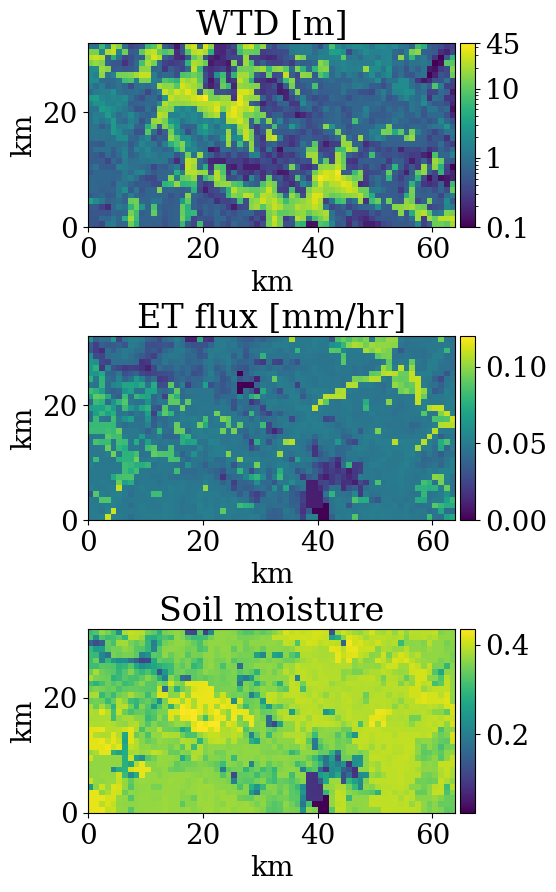

Saved plotting variables to: lil_washita_via_conus2_little_washita_plotvars_sim_typecap_cycle1.npz


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable

# --- time averages ---
wtd_avg = np.mean(wtd, axis=0)

et_avg = np.mean(
    (clm_output_T_mmps + clm_output_Ebs_mmps) * 60 * 60,
    axis=0
)

sm_avg = np.mean(soil_moisture_2m, axis=0)

# avoid zeros for log scale
wtd_plot = np.where(wtd_avg <= 0, 0.01, wtd_avg)

# ------------------------------------------------
# COLUMN FIGURE (3 x 1)
# log WTD + full labels + compact spacing
# ------------------------------------------------
fig, ax = plt.subplots(3, 1, figsize=(5, 11))

# ==================================================
# Panel 1: WTD (LOG SCALE)
# ==================================================
im1 = ax[0].pcolormesh(
    x/1e3,
    y/1e3,
    wtd_plot,
    cmap="viridis",
    shading='auto',
    norm=LogNorm(vmin=0.1, vmax=45)
)

ax[0].set_title("WTD [m]")
ax[0].set_xlabel("km")
ax[0].set_ylabel("km")
ax[0].set_aspect('equal')

# same-height colorbar
divider = make_axes_locatable(ax[0])
cax = divider.append_axes("right", size="4%", pad=0.05)

cbar1 = plt.colorbar(im1, cax=cax)
cbar1.set_ticks([0.1, 1, 10, 45])
cbar1.set_ticklabels(['0.1', '1', '10', '45'])

# ==================================================
# Panel 2: ET
# ==================================================
im2 = ax[1].pcolormesh(
    x/1e3,
    y/1e3,
    et_avg,
    cmap="viridis",
    shading='auto',
    vmin=0,
    vmax=0.12
)

ax[1].set_title("ET flux [mm/hr]")
ax[1].set_xlabel("km")
ax[1].set_ylabel("km")
ax[1].set_aspect('equal')

divider = make_axes_locatable(ax[1])
cax = divider.append_axes("right", size="4%", pad=0.05)

plt.colorbar(im2, cax=cax)

# ==================================================
# Panel 3: Soil Moisture
# ==================================================
im3 = ax[2].pcolormesh(
    x/1e3,
    y/1e3,
    sm_avg,
    cmap="viridis",
    shading='auto'
)

ax[2].set_title("Soil moisture")
ax[2].set_xlabel("km")
ax[2].set_ylabel("km")
ax[2].set_aspect('equal')

divider = make_axes_locatable(ax[2])
cax = divider.append_axes("right", size="4%", pad=0.05)

plt.colorbar(im3, cax=cax)

# ------------------------------------------------
# Reduce vertical space between panels
# ------------------------------------------------
fig.subplots_adjust(hspace=0.12)

# save
plt.savefig(
    f'little_washita_3panel_column_logWTD_sim_type{sim_type}_cycle{cycle}.pdf',
    bbox_inches='tight',
    dpi=600
)

plt.savefig(
    f'little_washita_3panel_column_logWTD_sim_type{sim_type}_cycle{cycle}.png',
    bbox_inches='tight',
    dpi=600
)

plt.show()


# ==================================================
# Save variables for replotting/comparison
# ==================================================

save_file = (
    f"{run_name}_little_washita_plotvars_"
    f"sim_type{sim_type}_cycle{cycle}.npz"
)

np.savez_compressed(
    save_file,

    # coordinates
    x=x,
    y=y,

    # plotted fields
    wtd_avg=wtd_avg,
    wtd_plot=wtd_plot,   # log-safe version
    et_avg=et_avg,
    sm_avg=sm_avg,

    # plotting settings
    wtd_vmin=0.1,
    wtd_vmax=45,
    et_vmin=0.0,
    et_vmax=0.12,

    # metadata
    sim_type=sim_type,
    cycle=cycle
)

print(f"Saved plotting variables to: {save_file}")


In [12]:
np.mean(et_avg)*24

#Mean ET flux throughout the year [mm/day]

np.float64(1.2095302357624491)

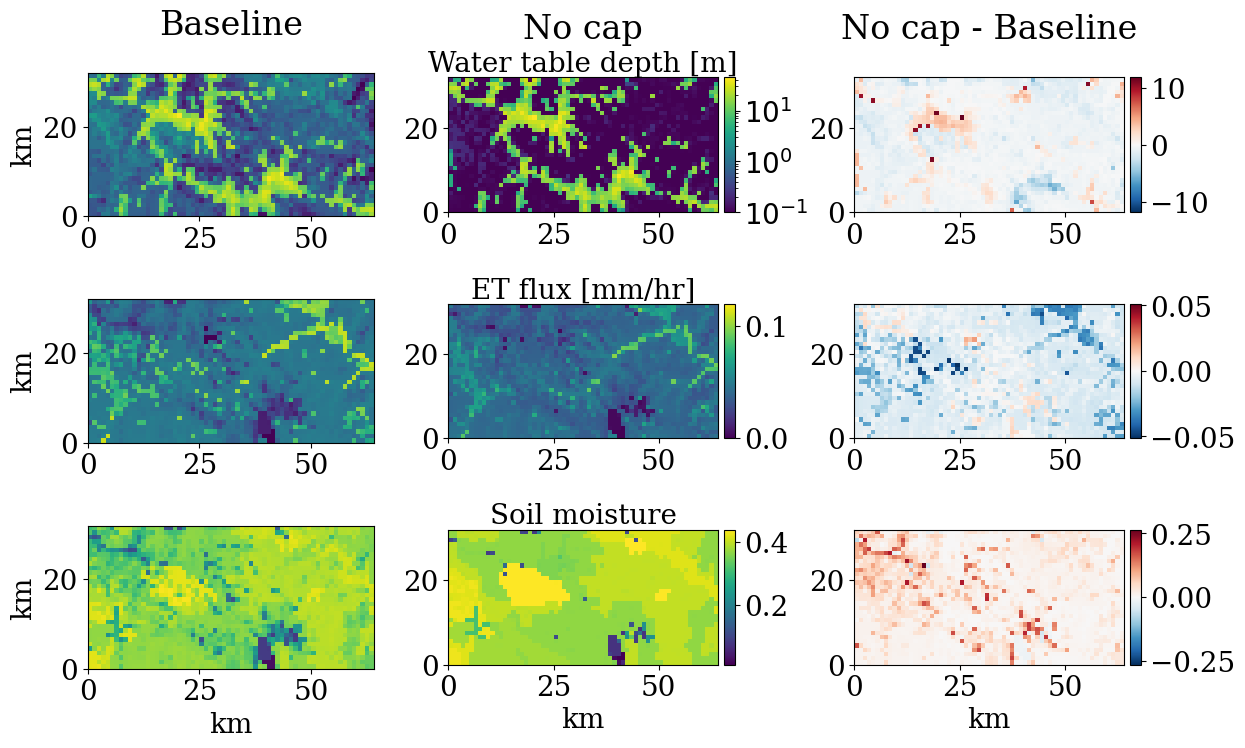

ET difference (no cap - cap) [mm/hr] -0.008373817544059109
WTD difference (no cap - cap) [m] -0.3171882933302239
SM difference (no cap - cap) [-] 0.026077620376192642
ET difference (no cap - cap) [%] -16.61567566607647
WTD difference (no cap - cap) [%] -6.878755014616774
SM difference (no cap - cap) [%] 7.337527707898707


In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, TwoSlopeNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable
plt.rcParams.update({'font.size': 20})
plt.rcParams.update({'font.family': 'Serif'})
# ==================================================
# Load files
# ==================================================
cap_file = "lil_washita_via_conus2_little_washita_plotvars_sim_typecap_cycle1.npz"

nocap_file = (
    "no_cap_lil_washita_via_conus2_cycle5_"
    "little_washita_plotvars_sim_typeno-cap_cycle5.npz"
)

cap = np.load(cap_file, allow_pickle=True)
nocap = np.load(nocap_file, allow_pickle=True)

# ==================================================
# Coordinates
# ==================================================
x = cap["x"] / 1e3
y = cap["y"] / 1e3

# ==================================================
# Variables
# ==================================================
wtd_cap = cap["wtd_avg"]
et_cap  = cap["et_avg"]
sm_cap  = cap["sm_avg"]

wtd_nocap = nocap["wtd_avg"]
et_nocap  = nocap["et_avg"]
sm_nocap  = nocap["sm_avg"]

# ==================================================
# Log-safe WTD
# ==================================================
wtd_cap_plot = np.where(wtd_cap <= 0, 0.01, wtd_cap)
wtd_nocap_plot = np.where(wtd_nocap <= 0, 0.01, wtd_nocap)

# ==================================================
# Differences: No cap - Baseline
# ==================================================
wtd_diff = wtd_nocap - wtd_cap
et_diff  = et_nocap - et_cap
sm_diff  = sm_nocap - sm_cap

# ==================================================
# Color limits
# ==================================================
wtd_norm = LogNorm(vmin=0.1, vmax=45)

sm_vmin = min(np.nanmin(sm_cap), np.nanmin(sm_nocap))
sm_vmax = max(np.nanmax(sm_cap), np.nanmax(sm_nocap))

wtd_dmax = np.nanmax(np.abs(wtd_diff))
et_dmax  = np.nanmax(np.abs(et_diff))
sm_dmax  = np.nanmax(np.abs(sm_diff))


if wtd_dmax == 0:
    wtd_dmax = 1
if et_dmax == 0:
    et_dmax = 1
if sm_dmax == 0:
    sm_dmax = 1

# ==================================================
# Figure
# ==================================================
fig, ax = plt.subplots(3, 3, figsize=(13, 9))

# ==================================================
# Column titles only once
# ==================================================
column_titles = ["Baseline", "No cap", "No cap - Baseline"]

for j in range(3):
    ax[0, j].set_title(column_titles[j], pad=28)

# ==================================================
# Row 1: Water table depth
# ==================================================
im00 = ax[0, 0].pcolormesh(
    x, y, wtd_cap_plot,
    cmap="viridis",
    shading="auto",
    norm=wtd_norm
)

im01 = ax[0, 1].pcolormesh(
    x, y, wtd_nocap_plot,
    cmap="viridis",
    shading="auto",
    norm=wtd_norm
)

im02 = ax[0, 2].pcolormesh(
    x, y, wtd_diff,
    cmap="RdBu_r",
    shading="auto",
    norm=TwoSlopeNorm(vmin=-wtd_dmax, vcenter=0, vmax=wtd_dmax)
)

ax[0, 1].text(
    0.5, 1.00,
    "Water table depth [m]",
    transform=ax[0, 1].transAxes,
    ha="center",
    va="bottom"
)

divider = make_axes_locatable(ax[0, 1])
cax = divider.append_axes("right", size="4%", pad=0.06)

cbar = fig.colorbar(im00, cax=cax)
cbar.set_ticks([0.1, 1, 10])
cbar.set_ticklabels([r"$10^{-1}$", r"$10^{0}$", r"$10^{1}$"])

divider = make_axes_locatable(ax[0, 2])
cax = divider.append_axes("right", size="4%", pad=0.06)
fig.colorbar(im02, cax=cax)

# ==================================================
# Row 2: ET
# ==================================================
im10 = ax[1, 0].pcolormesh(
    x, y, et_cap,
    cmap="viridis",
    shading="auto",
    vmin=0,
    vmax=0.12
)

im11 = ax[1, 1].pcolormesh(
    x, y, et_nocap,
    cmap="viridis",
    shading="auto",
    vmin=0,
    vmax=0.12
)

im12 = ax[1, 2].pcolormesh(
    x, y, et_diff,
    cmap="RdBu_r",
    shading="auto",
    norm=TwoSlopeNorm(vmin=-et_dmax, vcenter=0, vmax=et_dmax)
)

ax[1, 1].text(
    0.5, 1.00,
    "ET flux [mm/hr]",
    transform=ax[1, 1].transAxes,
    ha="center",
    va="bottom"
)

divider = make_axes_locatable(ax[1, 1])
cax = divider.append_axes("right", size="4%", pad=0.06)
fig.colorbar(im10, cax=cax)

divider = make_axes_locatable(ax[1, 2])
cax = divider.append_axes("right", size="4%", pad=0.06)
fig.colorbar(im12, cax=cax)

# ==================================================
# Row 3: Soil moisture
# ==================================================
im20 = ax[2, 0].pcolormesh(
    x, y, sm_cap,
    cmap="viridis",
    shading="auto",
    vmin=sm_vmin,
    vmax=sm_vmax
)

im21 = ax[2, 1].pcolormesh(
    x, y, sm_nocap,
    cmap="viridis",
    shading="auto",
    vmin=sm_vmin,
    vmax=sm_vmax
)

im22 = ax[2, 2].pcolormesh(
    x, y, sm_diff,
    cmap="RdBu_r",
    shading="auto",
    norm=TwoSlopeNorm(vmin=-sm_dmax, vcenter=0, vmax=sm_dmax)
)

ax[2, 1].text(
    0.5, 1.00,
    "Soil moisture",
    transform=ax[2, 1].transAxes,
    ha="center",
    va="bottom"
)

divider = make_axes_locatable(ax[2, 1])
cax = divider.append_axes("right", size="4%", pad=0.06)
fig.colorbar(im20, cax=cax)

divider = make_axes_locatable(ax[2, 2])
cax = divider.append_axes("right", size="4%", pad=0.06)
fig.colorbar(im22, cax=cax)

# ==================================================
# Formatting
# ==================================================
for i in range(3):
    for j in range(3):

        ax[i, j].set_aspect("equal")

        if i == 2:
            ax[i, j].set_xlabel("km")
        else:
            ax[i, j].set_xlabel("")

        if j == 0:
            ax[i, j].set_ylabel("km")
        else:
            ax[i, j].set_ylabel("")
'''
# ==================================================
# Panel labels
# ==================================================
panel_labels = [
    "(a)", "(b)", "(c)",
    "(d)", "(e)", "(f)",
    "(g)", "(h)", "(i)"
]

k = 0
for i in range(3):
    for j in range(3):
        ax[i, j].text(
            0.03, 0.04,
            panel_labels[k],
            transform=ax[i, j].transAxes,
            fontsize=20,
            color="black",
            ha="left",
            va="bottom"
        )
        k += 1
'''
# ==================================================
# Spacing
# ==================================================
fig.subplots_adjust(
    wspace=0.26,
    hspace=-0.06
)

# Increase space between No cap and Difference
for i in range(3):
    pos = ax[i, 2].get_position()

    ax[i, 2].set_position([
        pos.x0 + 0.035,
        pos.y0,
        pos.width,
        pos.height
    ])

# ==================================================
# Save
# ==================================================
plt.savefig(
    "little_washita_baseline_vs_nocap_9panel_old.png",
    bbox_inches="tight",
    dpi=600
)

plt.savefig(
    "little_washita_baseline_vs_nocap_9panel_old.pdf",
    bbox_inches="tight",
    dpi=600
)

plt.show()


print('ET difference (no cap - cap) [mm/hr]',  np.mean(et_diff))
print('WTD difference (no cap - cap) [m]', np.mean(wtd_diff))
print('SM difference (no cap - cap) [-]',  np.mean(sm_diff))
print('ET difference (no cap - cap) [%]',  np.mean(et_diff)/np.mean(et_cap)*100)
print('WTD difference (no cap - cap) [%]', np.mean(wtd_diff)/np.mean(wtd_cap)*100)
print('SM difference (no cap - cap) [%]',  np.mean(sm_diff)/np.mean(sm_cap)*100)


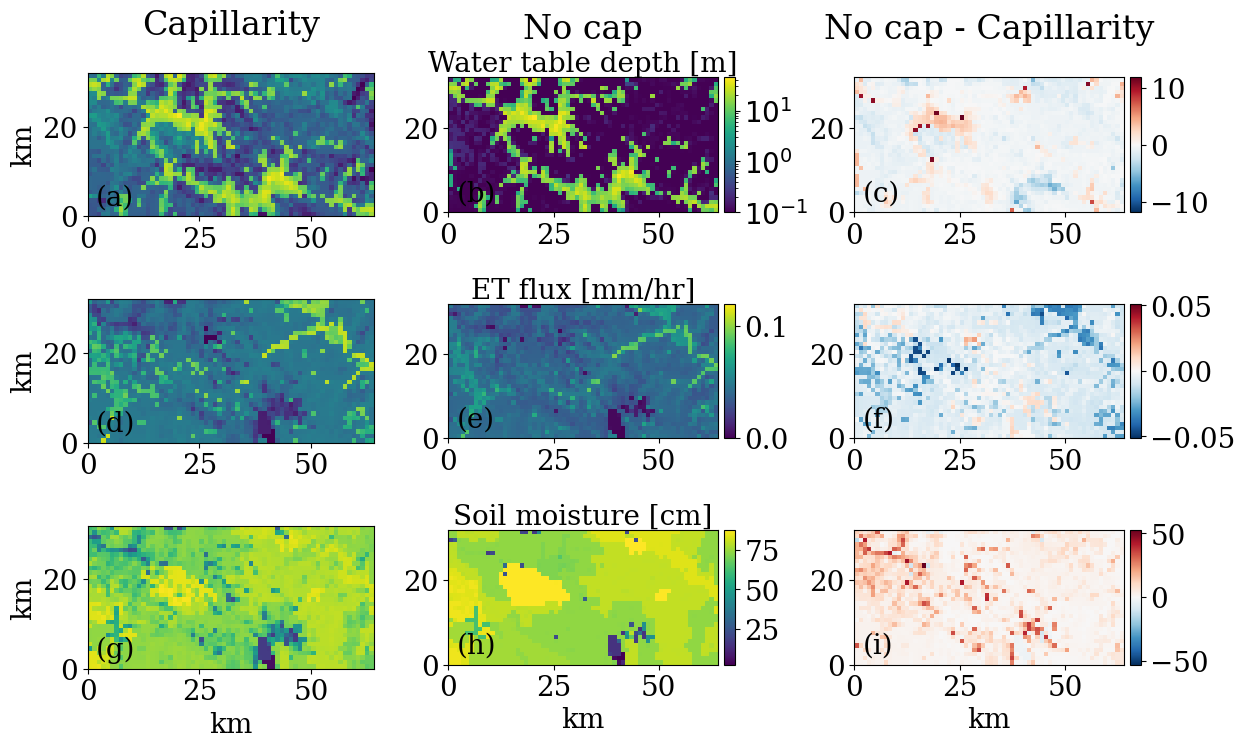

ET difference (no cap - cap) [mm/hr] -0.008373817544059109
WTD difference (no cap - cap) [m] -0.3171882933302239
SM difference (no cap - cap) [cm] 5.215524075238529
ET difference (no cap - cap) [%] -16.61567566607647
WTD difference (no cap - cap) [%] -6.878755014616774
SM difference (no cap - cap) [%] 7.337527707898707


In [21]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, TwoSlopeNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable
plt.rcParams.update({'font.size': 20})
plt.rcParams.update({'font.family': 'Serif'})
# ==================================================
# Load files
# ==================================================
cap_file = "lil_washita_via_conus2_little_washita_plotvars_sim_typecap_cycle1.npz"

nocap_file = (
    "no_cap_lil_washita_via_conus2_cycle5_"
    "little_washita_plotvars_sim_typeno-cap_cycle5.npz"
)

cap = np.load(cap_file, allow_pickle=True)
nocap = np.load(nocap_file, allow_pickle=True)

# ==================================================
# Coordinates
# ==================================================
x = cap["x"] / 1e3
y = cap["y"] / 1e3

# ==================================================
# Variables
# ==================================================
wtd_cap = cap["wtd_avg"]
et_cap  = cap["et_avg"]
sm_cap  = cap["sm_avg"]

wtd_nocap = nocap["wtd_avg"]
et_nocap  = nocap["et_avg"]
sm_nocap  = nocap["sm_avg"]

# ==================================================
# Log-safe WTD
# ==================================================
wtd_cap_plot = np.where(wtd_cap <= 0, 0.01, wtd_cap)
wtd_nocap_plot = np.where(wtd_nocap <= 0, 0.01, wtd_nocap)

# ==================================================
# Differences: No cap - Baseline
# ==================================================
wtd_diff = wtd_nocap - wtd_cap
et_diff  = et_nocap - et_cap
sm_diff  = sm_nocap - sm_cap

# ==================================================
# Color limits
# ==================================================
wtd_norm = LogNorm(vmin=0.1, vmax=45)

sm_vmin = min(np.nanmin(sm_cap), np.nanmin(sm_nocap))
sm_vmax = max(np.nanmax(sm_cap), np.nanmax(sm_nocap))

wtd_dmax = np.nanmax(np.abs(wtd_diff))
et_dmax  = np.nanmax(np.abs(et_diff))
sm_dmax  = np.nanmax(np.abs(sm_diff))


if wtd_dmax == 0:
    wtd_dmax = 1
if et_dmax == 0:
    et_dmax = 1
if sm_dmax == 0:
    sm_dmax = 1

# ==================================================
# Figure
# ==================================================
fig, ax = plt.subplots(3, 3, figsize=(13, 9))

# ==================================================
# Column titles only once
# ==================================================
column_titles = ["Capillarity", "No cap", "No cap - Capillarity"]

for j in range(3):
    ax[0, j].set_title(column_titles[j], pad=28)

# ==================================================
# Row 1: Water table depth
# ==================================================
im00 = ax[0, 0].pcolormesh(
    x, y, wtd_cap_plot,
    cmap="viridis",
    shading="auto",
    norm=wtd_norm
)

im01 = ax[0, 1].pcolormesh(
    x, y, wtd_nocap_plot,
    cmap="viridis",
    shading="auto",
    norm=wtd_norm
)

im02 = ax[0, 2].pcolormesh(
    x, y, wtd_diff,
    cmap="RdBu_r",
    shading="auto",
    norm=TwoSlopeNorm(vmin=-wtd_dmax, vcenter=0, vmax=wtd_dmax)
)

ax[0, 1].text(
    0.5, 1.00,
    "Water table depth [m]",
    transform=ax[0, 1].transAxes,
    ha="center",
    va="bottom"
)

divider = make_axes_locatable(ax[0, 1])
cax = divider.append_axes("right", size="4%", pad=0.06)

cbar = fig.colorbar(im00, cax=cax)
cbar.set_ticks([0.1, 1, 10])
cbar.set_ticklabels([r"$10^{-1}$", r"$10^{0}$", r"$10^{1}$"])

divider = make_axes_locatable(ax[0, 2])
cax = divider.append_axes("right", size="4%", pad=0.06)
fig.colorbar(im02, cax=cax)

# ==================================================
# Row 2: ET
# ==================================================
im10 = ax[1, 0].pcolormesh(
    x, y, et_cap,
    cmap="viridis",
    shading="auto",
    vmin=0,
    vmax=0.12
)

im11 = ax[1, 1].pcolormesh(
    x, y, et_nocap,
    cmap="viridis",
    shading="auto",
    vmin=0,
    vmax=0.12
)

im12 = ax[1, 2].pcolormesh(
    x, y, et_diff,
    cmap="RdBu_r",
    shading="auto",
    norm=TwoSlopeNorm(vmin=-et_dmax, vcenter=0, vmax=et_dmax)
)

ax[1, 1].text(
    0.5, 1.00,
    "ET flux [mm/hr]",
    transform=ax[1, 1].transAxes,
    ha="center",
    va="bottom"
)

divider = make_axes_locatable(ax[1, 1])
cax = divider.append_axes("right", size="4%", pad=0.06)
fig.colorbar(im10, cax=cax)

divider = make_axes_locatable(ax[1, 2])
cax = divider.append_axes("right", size="4%", pad=0.06)
fig.colorbar(im12, cax=cax)

# ==================================================
# Row 3: Soil moisture
# ==================================================
im20 = ax[2, 0].pcolormesh(
    x, y, sm_cap*200,
    cmap="viridis",
    shading="auto",
    vmin=sm_vmin*200,
    vmax=sm_vmax*200
)

im21 = ax[2, 1].pcolormesh(
    x, y, sm_nocap*200,
    cmap="viridis",
    shading="auto",
    vmin=sm_vmin*200,
    vmax=sm_vmax*200
)

im22 = ax[2, 2].pcolormesh(
    x, y, sm_diff*200,
    cmap="RdBu_r",
    shading="auto",
    norm=TwoSlopeNorm(vmin=-sm_dmax*200, vcenter=0, vmax=sm_dmax*200)
)

ax[2, 1].text(
    0.5, 1.00,
    "Soil moisture [cm]",
    transform=ax[2, 1].transAxes,
    ha="center",
    va="bottom"
)

divider = make_axes_locatable(ax[2, 1])
cax = divider.append_axes("right", size="4%", pad=0.06)
fig.colorbar(im20, cax=cax)

divider = make_axes_locatable(ax[2, 2])
cax = divider.append_axes("right", size="4%", pad=0.06)
fig.colorbar(im22, cax=cax)

# ==================================================
# Formatting
# ==================================================
for i in range(3):
    for j in range(3):

        ax[i, j].set_aspect("equal")

        if i == 2:
            ax[i, j].set_xlabel("km")
        else:
            ax[i, j].set_xlabel("")

        if j == 0:
            ax[i, j].set_ylabel("km")
        else:
            ax[i, j].set_ylabel("")

# ==================================================
# Panel labels
# ==================================================
panel_labels = [
    "(a)", "(b)", "(c)",
    "(d)", "(e)", "(f)",
    "(g)", "(h)", "(i)"
]

k = 0
for i in range(3):
    for j in range(3):
        ax[i, j].text(
            0.03, 0.04,
            panel_labels[k],
            transform=ax[i, j].transAxes,
            fontsize=20,
            color="black",
            ha="left",
            va="bottom"
        )
        k += 1

# ==================================================
# Spacing
# ==================================================
fig.subplots_adjust(
    wspace=0.26,
    hspace=-0.06
)

# Increase space between No cap and Difference
for i in range(3):
    pos = ax[i, 2].get_position()

    ax[i, 2].set_position([
        pos.x0 + 0.035,
        pos.y0,
        pos.width,
        pos.height
    ])

# ==================================================
# Save
# ==================================================
plt.savefig(
    "little_washita_baseline_vs_nocap_9panel.png",
    bbox_inches="tight",
    dpi=600
)

plt.savefig(
    "little_washita_baseline_vs_nocap_9panel.pdf",
    bbox_inches="tight",
    dpi=600
)

plt.show()


print('ET difference (no cap - cap) [mm/hr]',  np.mean(et_diff))
print('WTD difference (no cap - cap) [m]', np.mean(wtd_diff))
print('SM difference (no cap - cap) [cm]',  np.mean(sm_diff)*200)
print('ET difference (no cap - cap) [%]',  np.mean(et_diff)/np.mean(et_cap)*100)
print('WTD difference (no cap - cap) [%]', np.mean(wtd_diff)/np.mean(wtd_cap)*100)
print('SM difference (no cap - cap) [%]',  np.mean(sm_diff)/np.mean(sm_cap)*100)


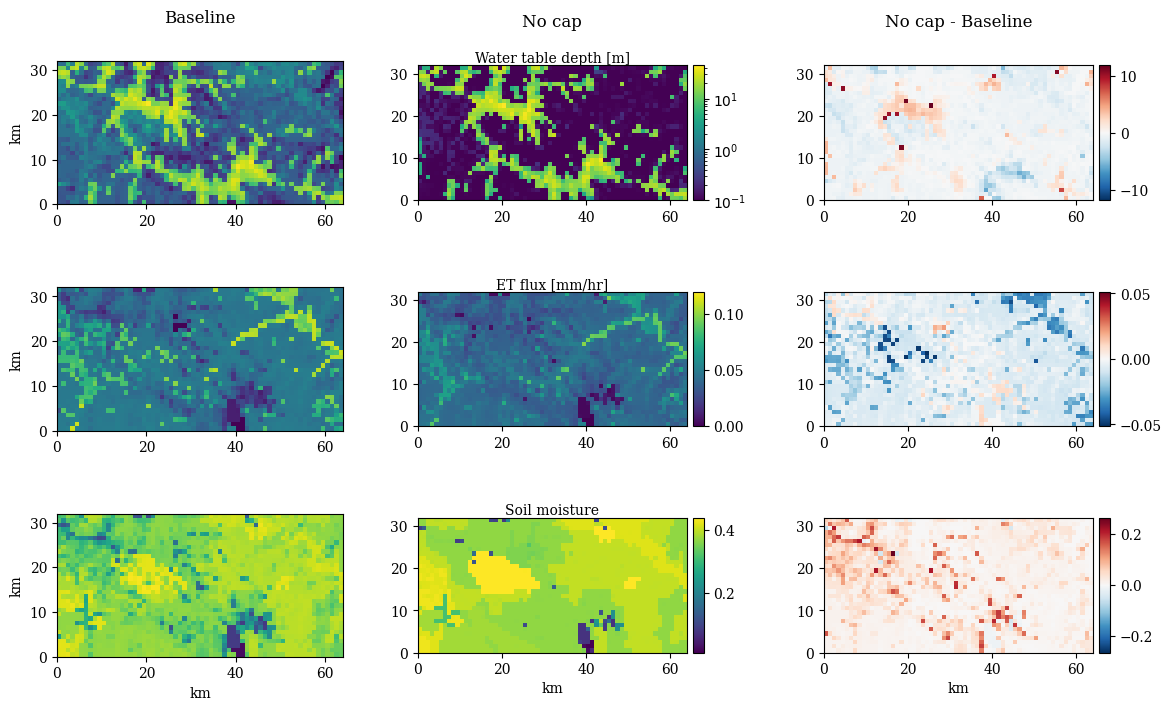

ET difference (no cap - cap) [mm/hr] -0.008373817544059109
WTD difference (no cap - cap) [m] -0.3171882933302239
SM difference (no cap - cap) [-] 0.026077620376192642
ET difference (no cap - cap) [%] -16.61567566607647
WTD difference (no cap - cap) [%] -6.878755014616774
SM difference (no cap - cap) [%] 7.337527707898707


In [15]:
plt.rcParams.update({'font.size': 17})
plt.rcParams.update({'font.family': 'Serif'})

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, TwoSlopeNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable
plt.rcParams.update({'font.size': 10})
plt.rcParams.update({'font.family': 'Serif'})
# ==================================================
# Load files
# ==================================================
cap_file = "lil_washita_via_conus2_little_washita_plotvars_sim_typecap_cycle1.npz"

nocap_file = (
    "no_cap_lil_washita_via_conus2_cycle5_"
    "little_washita_plotvars_sim_typeno-cap_cycle5.npz"
)

cap = np.load(cap_file, allow_pickle=True)
nocap = np.load(nocap_file, allow_pickle=True)

# ==================================================
# Coordinates
# ==================================================
x = cap["x"] / 1e3
y = cap["y"] / 1e3

# ==================================================
# Variables
# ==================================================
wtd_cap = cap["wtd_avg"]
et_cap  = cap["et_avg"]
sm_cap  = cap["sm_avg"]

wtd_nocap = nocap["wtd_avg"]
et_nocap  = nocap["et_avg"]
sm_nocap  = nocap["sm_avg"]

# ==================================================
# Log-safe WTD
# ==================================================
wtd_cap_plot = np.where(wtd_cap <= 0, 0.01, wtd_cap)
wtd_nocap_plot = np.where(wtd_nocap <= 0, 0.01, wtd_nocap)

# ==================================================
# Differences: No cap - Baseline
# ==================================================
wtd_diff = wtd_nocap - wtd_cap
et_diff  = et_nocap - et_cap
sm_diff  = sm_nocap - sm_cap

# ==================================================
# Color limits
# ==================================================
wtd_norm = LogNorm(vmin=0.1, vmax=45)

sm_vmin = min(np.nanmin(sm_cap), np.nanmin(sm_nocap))
sm_vmax = max(np.nanmax(sm_cap), np.nanmax(sm_nocap))

wtd_dmax = np.nanmax(np.abs(wtd_diff))
et_dmax  = np.nanmax(np.abs(et_diff))
sm_dmax  = np.nanmax(np.abs(sm_diff))


if wtd_dmax == 0:
    wtd_dmax = 1
if et_dmax == 0:
    et_dmax = 1
if sm_dmax == 0:
    sm_dmax = 1

# ==================================================
# Figure
# ==================================================
fig, ax = plt.subplots(3, 3, figsize=(13, 9))

# ==================================================
# Column titles only once
# ==================================================
column_titles = ["Baseline", "No cap", "No cap - Baseline"]

for j in range(3):
    ax[0, j].set_title(column_titles[j], pad=28)

# ==================================================
# Row 1: Water table depth
# ==================================================
im00 = ax[0, 0].pcolormesh(
    x, y, wtd_cap_plot,
    cmap="viridis",
    shading="auto",
    norm=wtd_norm
)

im01 = ax[0, 1].pcolormesh(
    x, y, wtd_nocap_plot,
    cmap="viridis",
    shading="auto",
    norm=wtd_norm
)

im02 = ax[0, 2].pcolormesh(
    x, y, wtd_diff,
    cmap="RdBu_r",
    shading="auto",
    norm=TwoSlopeNorm(vmin=-wtd_dmax, vcenter=0, vmax=wtd_dmax)
)

ax[0, 1].text(
    0.5, 1.00,
    "Water table depth [m]",
    transform=ax[0, 1].transAxes,
    ha="center",
    va="bottom"
)

divider = make_axes_locatable(ax[0, 1])
cax = divider.append_axes("right", size="4%", pad=0.06)

cbar = fig.colorbar(im00, cax=cax)
cbar.set_ticks([0.1, 1, 10])
cbar.set_ticklabels([r"$10^{-1}$", r"$10^{0}$", r"$10^{1}$"])

divider = make_axes_locatable(ax[0, 2])
cax = divider.append_axes("right", size="4%", pad=0.06)
fig.colorbar(im02, cax=cax)

# ==================================================
# Row 2: ET
# ==================================================
im10 = ax[1, 0].pcolormesh(
    x, y, et_cap,
    cmap="viridis",
    shading="auto",
    vmin=0,
    vmax=0.12
)

im11 = ax[1, 1].pcolormesh(
    x, y, et_nocap,
    cmap="viridis",
    shading="auto",
    vmin=0,
    vmax=0.12
)

im12 = ax[1, 2].pcolormesh(
    x, y, et_diff,
    cmap="RdBu_r",
    shading="auto",
    norm=TwoSlopeNorm(vmin=-et_dmax, vcenter=0, vmax=et_dmax)
)

ax[1, 1].text(
    0.5, 1.00,
    "ET flux [mm/hr]",
    transform=ax[1, 1].transAxes,
    ha="center",
    va="bottom"
)

divider = make_axes_locatable(ax[1, 1])
cax = divider.append_axes("right", size="4%", pad=0.06)
fig.colorbar(im10, cax=cax)

divider = make_axes_locatable(ax[1, 2])
cax = divider.append_axes("right", size="4%", pad=0.06)
fig.colorbar(im12, cax=cax)

# ==================================================
# Row 3: Soil moisture
# ==================================================
im20 = ax[2, 0].pcolormesh(
    x, y, sm_cap,
    cmap="viridis",
    shading="auto",
    vmin=sm_vmin,
    vmax=sm_vmax
)

im21 = ax[2, 1].pcolormesh(
    x, y, sm_nocap,
    cmap="viridis",
    shading="auto",
    vmin=sm_vmin,
    vmax=sm_vmax
)

im22 = ax[2, 2].pcolormesh(
    x, y, sm_diff,
    cmap="RdBu_r",
    shading="auto",
    norm=TwoSlopeNorm(vmin=-sm_dmax, vcenter=0, vmax=sm_dmax)
)

ax[2, 1].text(
    0.5, 1.00,
    "Soil moisture",
    transform=ax[2, 1].transAxes,
    ha="center",
    va="bottom"
)

divider = make_axes_locatable(ax[2, 1])
cax = divider.append_axes("right", size="4%", pad=0.06)
fig.colorbar(im20, cax=cax)

divider = make_axes_locatable(ax[2, 2])
cax = divider.append_axes("right", size="4%", pad=0.06)
fig.colorbar(im22, cax=cax)

# ==================================================
# Formatting
# ==================================================
for i in range(3):
    for j in range(3):

        ax[i, j].set_aspect("equal")

        if i == 2:
            ax[i, j].set_xlabel("km")
        else:
            ax[i, j].set_xlabel("")

        if j == 0:
            ax[i, j].set_ylabel("km")
        else:
            ax[i, j].set_ylabel("")
'''
# ==================================================
# Panel labels
# ==================================================
panel_labels = [
    "(a)", "(b)", "(c)",
    "(d)", "(e)", "(f)",
    "(g)", "(h)", "(i)"
]

k = 0
for i in range(3):
    for j in range(3):
        ax[i, j].text(
            0.03, 0.04,
            panel_labels[k],
            transform=ax[i, j].transAxes,
            fontsize=20,
            color="black",
            ha="left",
            va="bottom"
        )
        k += 1
'''
# ==================================================
# Spacing
# ==================================================
fig.subplots_adjust(
    wspace=0.26,
    hspace=-0.06
)

# Increase space between No cap and Difference
for i in range(3):
    pos = ax[i, 2].get_position()

    ax[i, 2].set_position([
        pos.x0 + 0.035,
        pos.y0,
        pos.width,
        pos.height
    ])

# ==================================================
# Save
# ==================================================
plt.savefig(
    "little_washita_baseline_vs_nocap_9panel.png",
    bbox_inches="tight",
    dpi=600
)

plt.savefig(
    "little_washita_baseline_vs_nocap_9panel.pdf",
    bbox_inches="tight",
    dpi=600
)

plt.show()


print('ET difference (no cap - cap) [mm/hr]',  np.mean(et_diff))
print('WTD difference (no cap - cap) [m]', np.mean(wtd_diff))
print('SM difference (no cap - cap) [-]',  np.mean(sm_diff))
print('ET difference (no cap - cap) [%]',  np.mean(et_diff)/np.mean(et_cap)*100)
print('WTD difference (no cap - cap) [%]', np.mean(wtd_diff)/np.mean(wtd_cap)*100)
print('SM difference (no cap - cap) [%]',  np.mean(sm_diff)/np.mean(sm_cap)*100)


In [16]:
et_mmps = (clm_output_T_mmps + clm_output_Ebs_mmps)
print(np.shape(et_mmps))
et_avg = np.mean(
    (clm_output_T_mmps + clm_output_Ebs_mmps) * 60 * 60,
    axis=0  #ET in mm per hour
)

et_cum_p_hr_sum = np.sum(
    (clm_output_T_mmps + clm_output_Ebs_mmps) * 60 * 60,
    axis=(1,2)  
)*dx*dy*1e-3  #ET in m per hour


(8760, 32, 64)


### plotting components of water balance

148.82541220723581


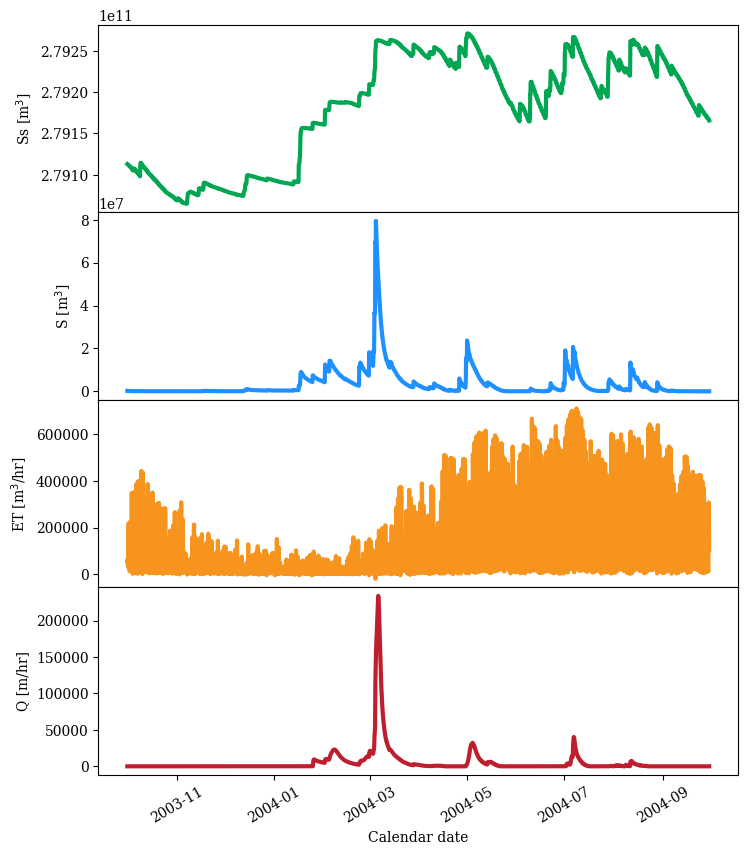

In [17]:
from datetime import datetime, timedelta
d = datetime(2003, 10, 1, 0, 0)

#print(d + timedelta(hours = time_array_plot[0,2]))
time_array_one_row = np.linspace(0,8760,8761)#time_array_plot[0,:]

time_array_datetime = ([d + timedelta(hours = i) for i in time_array_one_row])

#time_array_datetime = np.tile(t_time_datetime, (20,1))

#plotting components of water balance
fig, axs = plt.subplots(4, sharex=True, figsize=(8,10) , dpi=100)
#fig.suptitle('Little Washita Water Balance')
axs[0].plot(time_array_datetime,subsurface_storage, linewidth=3, color = green)
axs[0].set_ylabel("Ss [m$^3$]")
axs[1].plot(time_array_datetime,surface_storage, linewidth=3, color = blue)
axs[1].set_ylabel("S [m$^3$]")
#axs[2].plot(time_array_datetime,et, linewidth=3, color = orange)
axs[2].plot(time_array_datetime[:-1],et_cum_p_hr_sum, linewidth=3, color = orange)
axs[2].set_ylabel("ET [m$^3$/hr]")
axs[3].plot(time_array_datetime,overland_flow[:,24,50], linewidth=3, color = red)
axs[3].set_ylabel("Q [m/hr]")
plt.xlabel('Calendar date')
plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.9, 
                    top=0.85, 
                    wspace=0.0, 
                    hspace=0.0)
axs[1].ticklabel_format(axis='y', style='sci', scilimits=(0,0))
plt.xticks(rotation = 30)
plt.savefig(f'little_washita_time_sim_type{sim_type}_storage_cycle{cycle}.pdf',bbox_inches='tight', dpi = 600)
plt.savefig(f'little_washita_time_sim_type{sim_type}_storage_cycle{cycle}.png',bbox_inches='tight', dpi = 600)
np.savez(f'little_washita_time{icount}hr_sim_type{sim_type}_storage_cycle{cycle}',subsurface_storage,surface_storage,et_cum_p_hr_sum,overland_flow) 


print(np.max(et)/np.max(et_cum_p_hr_sum))

In [18]:
!pwd

/scratch/network/ms6985/ParFlow-Project-final/lil_washita


ValueError: x and y must have same first dimension, but have shapes (8761,) and (8760,)

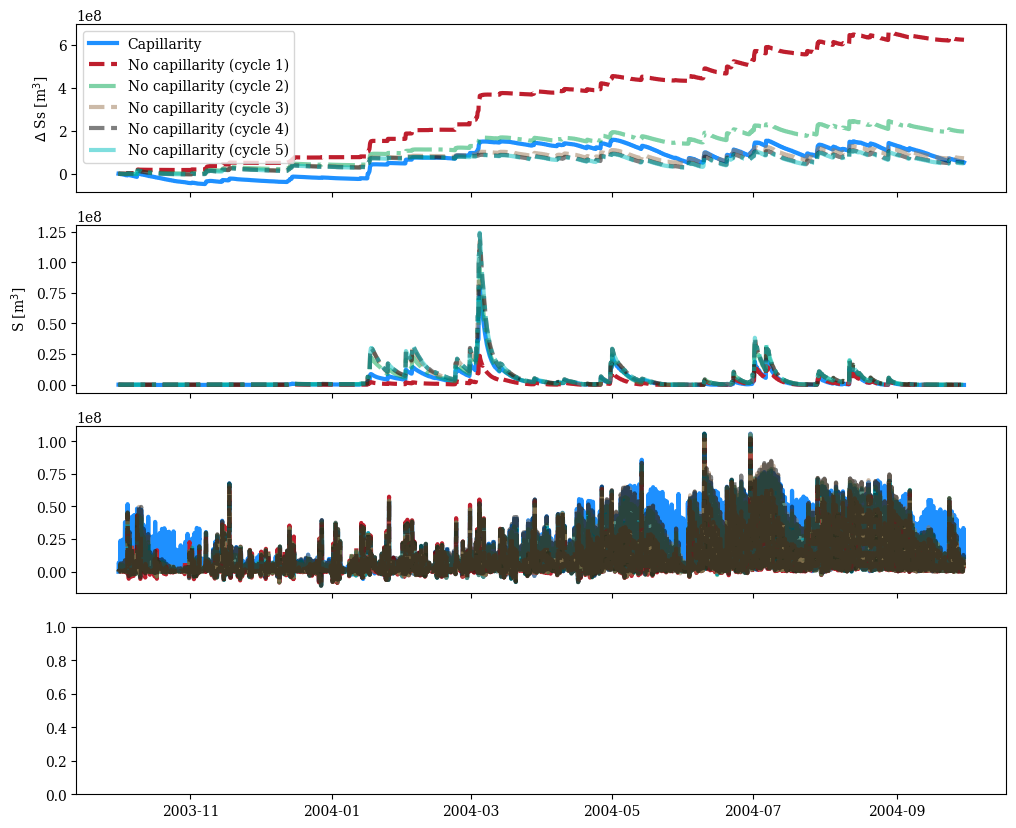

In [19]:
#Difference plots  subsurface_storage,surface_storage,et,overland_flow
no_cap = np.load(f'little_washita_time72hr_sim_typeno-cap_storage.npz'); subsurf_storage_no_cap = no_cap['arr_0']; surf_storage_no_cap = no_cap['arr_1']; et_no_cap = no_cap['arr_2']; overland_no_cap = no_cap['arr_3'];  
cap = np.load(f'little_washita_time72hr_sim_typecap_storage.npz'); subsurf_storage_cap = cap['arr_0']; surf_storage_cap = cap['arr_1']; et_cap = cap['arr_2']; overland_cap = cap['arr_3'];  
no_cap2 = np.load(f'little_washita_time72hr_sim_typeno-cap_storage_cycle2.npz'); subsurf_storage_no_cap2 = no_cap2['arr_0']; surf_storage_no_cap2 = no_cap2['arr_1']; et_no_cap2 = no_cap2['arr_2']; overland_no_cap2 = no_cap2['arr_3'];  
no_cap3 = np.load(f'little_washita_time72hr_sim_typeno-cap_storage_cycle3.npz'); subsurf_storage_no_cap3 = no_cap3['arr_0']; surf_storage_no_cap3 = no_cap3['arr_1']; et_no_cap3 = no_cap3['arr_2']; overland_no_cap3 = no_cap3['arr_3'];  
no_cap4 = np.load(f'little_washita_time72hr_sim_typeno-cap_storage_cycle4.npz'); subsurf_storage_no_cap4 = no_cap4['arr_0']; surf_storage_no_cap4 = no_cap4['arr_1']; et_no_cap4 = no_cap4['arr_2']; overland_no_cap4 = no_cap4['arr_3'];  
no_cap5 = np.load(f'little_washita_time72hr_sim_typeno-cap_storage_cycle5.npz'); subsurf_storage_no_cap5 = no_cap5['arr_0']; surf_storage_no_cap5 = no_cap5['arr_1']; et_no_cap5 = no_cap5['arr_2']; overland_no_cap5 = no_cap5['arr_3'];  


#plotting components of water balance
fig, axs = plt.subplots(4, sharex=True, figsize=(12,10) , dpi=100)
#fig.suptitle('Little Washita Water Balance')
axs[0].plot(time_array_datetime,subsurf_storage_cap-subsurf_storage_cap[0], linewidth=3, color = blue,linestyle='-',label='Capillarity')
axs[0].plot(time_array_datetime,subsurf_storage_no_cap-subsurf_storage_no_cap[0], linewidth=3, color = red,linestyle='--',label='No capillarity (cycle 1)')
axs[0].plot(time_array_datetime,subsurf_storage_no_cap2-subsurf_storage_no_cap2[0], linewidth=3, color = green,linestyle='-.',label='No capillarity (cycle 2)',alpha=0.5)
axs[0].plot(time_array_datetime,subsurf_storage_no_cap3-subsurf_storage_no_cap3[0], linewidth=3, color = brown,linestyle='--',label='No capillarity (cycle 3)',alpha=0.5)
axs[0].plot(time_array_datetime,subsurf_storage_no_cap4-subsurf_storage_no_cap4[0], linewidth=3, color = 'k',linestyle='--',label='No capillarity (cycle 4)',alpha=0.5)
axs[0].plot(time_array_datetime,subsurf_storage_no_cap5-subsurf_storage_no_cap5[0], linewidth=3, color = 'c',linestyle='-.',label='No capillarity (cycle 5)',alpha=0.5)


axs[0].legend(loc='best')
axs[0].set_ylabel("$\Delta$ Ss [m$^3$]")
axs[1].plot(time_array_datetime,surf_storage_cap-surf_storage_cap[0], linewidth=3, color = blue,linestyle='-')
axs[1].plot(time_array_datetime,surf_storage_no_cap-surf_storage_no_cap[0], linewidth=3, color = red,linestyle='--')
axs[1].plot(time_array_datetime,surf_storage_no_cap2-surf_storage_no_cap2[0], linewidth=3, color = green,linestyle='-.',alpha=0.5)
axs[1].plot(time_array_datetime,surf_storage_no_cap3-surf_storage_no_cap3[0], linewidth=3, color = brown,linestyle='--',alpha=0.5)
axs[1].plot(time_array_datetime,surf_storage_no_cap4-surf_storage_no_cap4[0], linewidth=3, color = 'k',linestyle='--',alpha=0.5)
axs[1].plot(time_array_datetime,surf_storage_no_cap5-surf_storage_no_cap5[0], linewidth=3, color = 'c',linestyle='-.',alpha=0.5)


axs[1].set_ylabel("S [m$^3$]")
axs[2].plot(time_array_datetime,et_cap, linewidth=3, color = blue,linestyle='-')
axs[2].plot(time_array_datetime,et_no_cap, linewidth=3, color = red,linestyle='--')
axs[2].plot(time_array_datetime,et_no_cap2, linewidth=3, color = green,linestyle='-.',alpha=0.5)
axs[2].plot(time_array_datetime,et_no_cap3, linewidth=3, color = brown,linestyle='--',alpha=0.5)
axs[2].plot(time_array_datetime,et_no_cap4, linewidth=3, color = 'k',linestyle='--',alpha=0.5)
axs[2].plot(time_array_datetime,et_no_cap5, linewidth=3, color = 'c',linestyle='-.',alpha=0.5)
axs[2].set_ylabel("ET [m$^3$/hr]")
axs[3].plot(time_array_datetime,overland_cap[:,24,50], linewidth=3, color = blue,linestyle='-')
axs[3].plot(time_array_datetime,overland_no_cap[:,24,50], linewidth=3, color = red,linestyle='--')
axs[3].plot(time_array_datetime,overland_no_cap2[:,24,50], linewidth=3, color = green,linestyle='-.',alpha=0.5)
axs[3].plot(time_array_datetime,overland_no_cap3[:,24,50], linewidth=3, color = brown,linestyle='--',alpha=0.5)
axs[3].plot(time_array_datetime,overland_no_cap4[:,24,50], linewidth=3, color = 'k',linestyle='--',alpha=0.5)
axs[3].plot(time_array_datetime,overland_no_cap4[:,24,50], linewidth=3, color = 'c',linestyle='-.',alpha=0.5)
axs[3].set_ylabel("Q [m/hr]")
plt.xlabel('Calendar date')
plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.9, 
                    top=0.85, 
                    wspace=0.0, 
                    hspace=0.0)
axs[1].ticklabel_format(axis='y', style='sci', scilimits=(0,0))
plt.xticks(rotation = 30)
plt.savefig(f'little_washita_time_sim_type{sim_type}_combined_cycle.pdf',bbox_inches='tight', dpi = 600) 
plt.savefig(f'little_washita_time_sim_type{sim_type}_combined_cycle.png',bbox_inches='tight', dpi = 600) 

print('All solutions with total in m3')
print('With capillarity: Surface storage',surf_storage_cap[-1]-subsurf_storage_cap[0],'Change in subsurface storage',subsurf_storage_cap[-1]-subsurf_storage_cap[0], 'ET',np.sum(et_cap))
print('Without capillarity: Surface storage',surf_storage_no_cap[-1]-subsurf_storage_no_cap[0],'Change in subsurface storage',subsurf_storage_no_cap[-1]-subsurf_storage_no_cap[0], 'ET',np.sum(et_no_cap))

In [ ]:
np.shape(data.clm_output(field='eflx_lh_tot'))

In [ ]:
#Difference plots  subsurface_storage,surface_storage,et,overland_flow
no_cap = np.load(f'little_washita_time72hr_sim_typeno-cap_storage_cycle5.npz'); subsurf_storage_no_cap = no_cap['arr_0']; surf_storage_no_cap = no_cap['arr_1']; et_no_cap = no_cap['arr_2']; overland_no_cap = no_cap['arr_3'];  
cap = np.load(f'little_washita_time72hr_sim_typecap_storage.npz'); subsurf_storage_cap = cap['arr_0']; surf_storage_cap = cap['arr_1']; et_cap = cap['arr_2']; overland_cap = cap['arr_3'];  

#plotting components of water balance
fig, axs = plt.subplots(3, sharex=True, figsize=(12,10) , dpi=100)
#fig.suptitle('Little Washita Water Balance')
axs[0].plot(time_array_datetime,subsurf_storage_cap-subsurf_storage_cap[0], linewidth=3, color = blue,linestyle='-',label='Capillarity')
axs[0].plot(time_array_datetime,subsurf_storage_no_cap-subsurf_storage_no_cap[0], linewidth=3, color = red,linestyle='--',label='No capillarity')
axs[0].legend(loc='best')
axs[0].set_ylabel("$\Delta$ Ss [m$^3$]")
axs[1].plot(time_array_datetime,surf_storage_cap, linewidth=3, color = blue,linestyle='-')
axs[1].plot(time_array_datetime,surf_storage_no_cap, linewidth=3, color = red,linestyle='--')
axs[1].set_ylabel("S [m$^3$]")
axs[2].plot(time_array_datetime,et_cap, linewidth=3, color = blue,linestyle='-')
axs[2].plot(time_array_datetime,et_no_cap, linewidth=3, color = red,linestyle='--')
axs[2].set_ylabel("ET [m$^3$/hr]")
plt.xlabel('Calendar date')
plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.9, 
                    top=0.85, 
                    wspace=0.0, 
                    hspace=0.0)
axs[1].ticklabel_format(axis='y', style='sci', scilimits=(0,0))
plt.xticks(rotation = 30)
plt.savefig(f'little_washita_time_year_sim_type{sim_type}_combined_no_Q_spun_up.pdf',bbox_inches='tight', dpi = 600) 
plt.savefig(f'little_washita_time_year_sim_type{sim_type}_combined_no_Q_spun_up.png',bbox_inches='tight', dpi = 600) 

print('All solutions with total in m3')
print('With capillarity: Surface storage',surf_storage_cap[-1]-subsurf_storage_cap[0],'Change in subsurface storage',subsurf_storage_cap[-1]-subsurf_storage_cap[0], 'ET',np.sum(et_cap))
print('Without capillarity: Surface storage',surf_storage_no_cap[-1]-subsurf_storage_no_cap[0],'Change in subsurface storage',subsurf_storage_no_cap[-1]-subsurf_storage_no_cap[0], 'ET',np.sum(et_no_cap))

In [ ]:
#Difference plots  subsurface_storage,surface_storage,et,overland_flow
no_cap = np.load(f'little_washita_time72hr_sim_typeno-cap_storage_cycle5.npz'); subsurf_storage_no_cap = no_cap['arr_0']; surf_storage_no_cap = no_cap['arr_1']; et_no_cap = no_cap['arr_2']; overland_no_cap = no_cap['arr_3'];  
cap = np.load(f'little_washita_time72hr_sim_typecap_storage.npz'); subsurf_storage_cap = cap['arr_0']; surf_storage_cap = cap['arr_1']; et_cap = cap['arr_2']; overland_cap = cap['arr_3'];  

#plotting components of water balance
fig, axs = plt.subplots(3, sharex=True, figsize=(12,10) , dpi=100)
#fig.suptitle('Little Washita Water Balance')
axs[0].plot(time_array_datetime,subsurf_storage_cap, linewidth=3, color = blue,linestyle='-',label='Capillarity')
#ax2=axs[0].twinx()
axs[0].plot(time_array_datetime,subsurf_storage_no_cap, linewidth=3, color = red,linestyle='--',label='No capillarity')
axs[0].legend(loc='best')
axs[0].set_ylabel("Ss [m$^3$]")
axs[1].plot(time_array_datetime,surf_storage_cap, linewidth=3, color = blue,linestyle='-')
axs[1].plot(time_array_datetime,surf_storage_no_cap, linewidth=3, color = red,linestyle='--')
axs[1].set_ylabel("S [m$^3$]")
axs[2].plot(time_array_datetime,et_cap, linewidth=3, color = blue,linestyle='-')
axs[2].plot(time_array_datetime,et_no_cap, linewidth=3, color = red,linestyle='--')
axs[2].set_ylabel("ET [m$^3$/hr]")
plt.xlabel('Calendar date')
plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.9, 
                    top=0.85, 
                    wspace=0.0, 
                    hspace=0.0)
axs[1].ticklabel_format(axis='y', style='sci', scilimits=(0,0))
plt.xticks(rotation = 30)
plt.savefig(f'little_washita_time_year_sim_type{sim_type}_combined_no_Q_spun_up_abs.pdf',bbox_inches='tight', dpi = 600) 
plt.savefig(f'little_washita_time_year_sim_type{sim_type}_combined_no_Q_spun_up_abs.png',bbox_inches='tight', dpi = 600) 

print('All solutions with total in m3')
print('With capillarity: Surface storage',surf_storage_cap[-1]-subsurf_storage_cap[0],'Change in subsurface storage',subsurf_storage_cap[-1]-subsurf_storage_cap[0], 'ET',np.sum(et_cap))
print('Without capillarity: Surface storage',surf_storage_no_cap[-1]-subsurf_storage_no_cap[0],'Change in subsurface storage',subsurf_storage_no_cap[-1]-subsurf_storage_no_cap[0], 'ET',np.sum(et_no_cap))
print('Percentage: Surface storage',(surf_storage_no_cap[-1]-subsurf_storage_no_cap[0]-surf_storage_cap[-1]-subsurf_storage_cap[0])/(surf_storage_cap[-1]-subsurf_storage_cap[0])*100,'Change in subsurface storage',(subsurf_storage_no_cap[-1]-subsurf_storage_no_cap[0]-(subsurf_storage_cap[-1]-subsurf_storage_cap[0]))/(subsurf_storage_cap[-1]-subsurf_storage_cap[0])*100, 'ET',(np.sum(et_no_cap)-np.sum(et_cap))/(np.sum(et_cap))*100)
